In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from sklearn.metrics import roc_curve, auc, roc_auc_score
from hydra import compose, initialize
import joblib

import xgboost as xgb
from vbf_tagger.models.MLPClassifier import MLPClassifier
from vbf_tagger.tools.data.flatpair_dataloader import FlatPairDataModule

plt.style.use(hep.style.CMS)

/opt/conda/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
with initialize(version_base=None, config_path="../config", job_name="compare"):
    cfg = compose(config_name="main")

In [3]:
dm = FlatPairDataModule(cfg)
dm.setup(stage="fit")
dm.setup(stage="test")

 Found 14 train files, 14 val files
 Class balance (train): 110329 positives, 1736268 negatives → pos_weight=15.74
 Found 14 test files


In [4]:
X_train = dm.train_dataset.tensors[0]
y_train = dm.train_dataset.tensors[1]
X_test  = dm.test_dataset.tensors[0]
y_test  = dm.test_dataset.tensors[1]

In [11]:
# MLPClassifier

ckpt_path = "/home/norman/vbf-tagger/outputs/MLP_251117/classification/models/model_best.ckpt"
checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)

hyperparams = checkpoint["hyper_parameters"]
mlp = MLPClassifier(**hyperparams)
mlp.load_state_dict(checkpoint["state_dict"])
mlp.eval()

# helper
def mlp_predict(X):
    with torch.no_grad():
        logits = mlp(X)
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()
        return np.clip(probs, 0, 1)

mlp_train = mlp_predict(X_train)
mlp_test  = mlp_predict(X_test)

In [6]:
# XGBoost

bst = xgb.Booster()
bst.load_model("/home/norman/vbf-tagger/XGBoost/xgboost_vbf_251117.json")

dtrain = xgb.DMatrix(X_train.numpy())
dtest  = xgb.DMatrix(X_test.numpy())

xgb_train = bst.predict(dtrain)
xgb_test  = bst.predict(dtest)

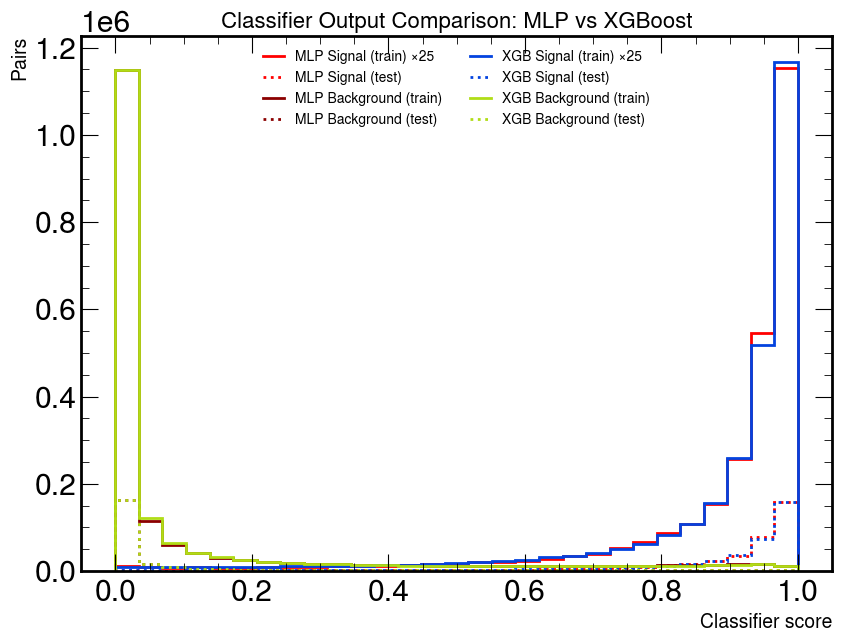

In [12]:
fig, ax = plt.subplots(figsize=(9,7))
bins = np.linspace(0, 1, 30)
signal_scale = 25

# MLP
hep.histplot(np.histogram(mlp_train[y_train==1], bins=bins)[0] * signal_scale,
             bins=bins, histtype='step', color='red', label=f"MLP Signal (train) ×{signal_scale}", linewidth=2)
hep.histplot(np.histogram(mlp_test[y_test==1], bins=bins)[0] * signal_scale,
             bins=bins, histtype='step', color='red', linestyle=':', label="MLP Signal (test)", linewidth=2)

hep.histplot(np.histogram(mlp_train[y_train==0], bins=bins)[0],
             bins=bins, histtype='step', color='darkred', label="MLP Background (train)", linewidth=2)
hep.histplot(np.histogram(mlp_test[y_test==0], bins=bins)[0],
             bins=bins, histtype='step', color='darkred', linestyle=':', label="MLP Background (test)", linewidth=2)

# XGBoost
hep.histplot(np.histogram(xgb_train[y_train==1], bins=bins)[0] * signal_scale,
             bins=bins, histtype='step', color='#0343df',
             label=f"XGB Signal (train) ×{signal_scale}", linewidth=2)
hep.histplot(np.histogram(xgb_test[y_test==1], bins=bins)[0] * signal_scale,
             bins=bins, histtype='step', color='#0343df', linestyle=':',
             label="XGB Signal (test)", linewidth=2)

hep.histplot(np.histogram(xgb_train[y_train==0], bins=bins)[0],
             bins=bins, histtype='step', color='#b0dd16',
             label="XGB Background (train)", linewidth=2)
hep.histplot(np.histogram(xgb_test[y_test==0], bins=bins)[0],
             bins=bins, histtype='step', color='#b0dd16', linestyle=':',
             label="XGB Background (test)", linewidth=2)

ax.set_xlabel("Classifier score", fontsize=14)
ax.set_ylabel("Pairs", fontsize=14)
ax.set_title("Classifier Output Comparison: MLP vs XGBoost", fontsize=16)
ax.legend(fontsize=10, ncol=2)
plt.tight_layout()
plt.show()

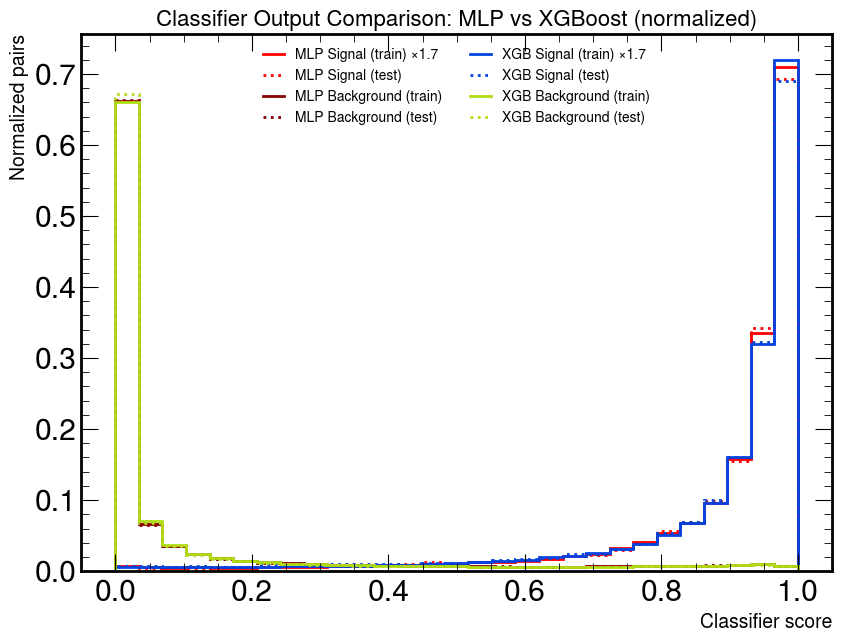

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import mplhep as hep

fig, ax = plt.subplots(figsize=(9,7))
bins = np.linspace(0, 1, 30)
signal_scale = 1.7   # purely visual scaling

# --- Helper for normalized hist counts ---
def normalized_hist(data, bins):
    hist, _ = np.histogram(data, bins=bins)
    return hist / hist.sum()    # normalize to area = 1


# ===========================
#        MLP
# ===========================

# Signal: scale * normalized
hep.histplot(
    normalized_hist(mlp_train[y_train==1], bins) * signal_scale,
    bins=bins, histtype='step', color='red',
    label=f"MLP Signal (train) ×{signal_scale}", linewidth=2
)
hep.histplot(
    normalized_hist(mlp_test[y_test==1], bins) * signal_scale,
    bins=bins, histtype='step', color='red', linestyle=':',
    label=f"MLP Signal (test)", linewidth=2
)

# Background
hep.histplot(
    normalized_hist(mlp_train[y_train==0], bins),
    bins=bins, histtype='step', color='darkred',
    label="MLP Background (train)", linewidth=2
)
hep.histplot(
    normalized_hist(mlp_test[y_test==0], bins),
    bins=bins, histtype='step', color='darkred', linestyle=':',
    label="MLP Background (test)", linewidth=2
)


# ===========================
#        XGBoost
# ===========================

hep.histplot(
    normalized_hist(xgb_train[y_train==1], bins) * signal_scale,
    bins=bins, histtype='step', color='#0343df',
    label=f"XGB Signal (train) ×{signal_scale}", linewidth=2
)
hep.histplot(
    normalized_hist(xgb_test[y_test==1], bins) * signal_scale,
    bins=bins, histtype='step', color='#0343df', linestyle=':',
    label="XGB Signal (test)", linewidth=2
)

hep.histplot(
    normalized_hist(xgb_train[y_train==0], bins),
    bins=bins, histtype='step', color='#b0dd16',
    label="XGB Background (train)", linewidth=2
)
hep.histplot(
    normalized_hist(xgb_test[y_test==0], bins),
    bins=bins, histtype='step', color='#b0dd16', linestyle=':',
    label="XGB Background (test)", linewidth=2
)


ax.set_xlabel("Classifier score", fontsize=14)
ax.set_ylabel("Normalized pairs", fontsize=14)
ax.set_title("Classifier Output Comparison: MLP vs XGBoost (normalized)", fontsize=16)
ax.legend(fontsize=10, ncol=2)
plt.tight_layout()
plt.show()


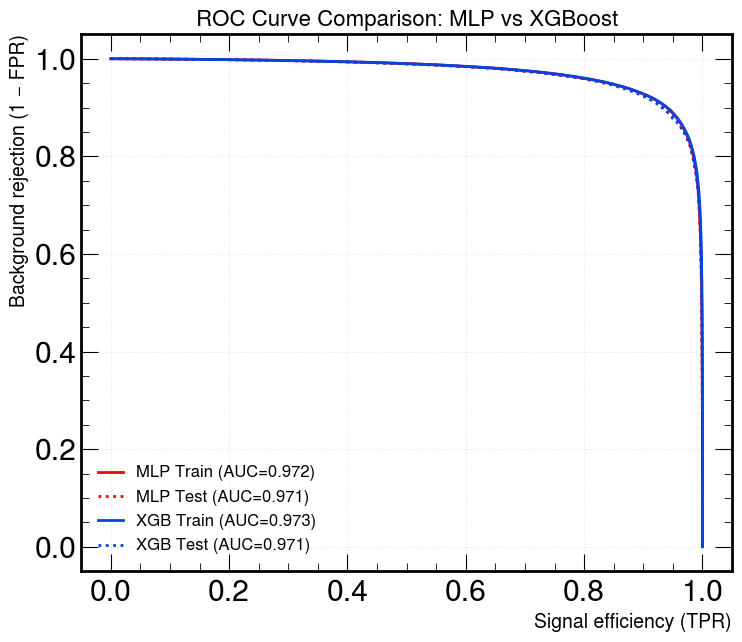

In [14]:
def compute_roc(y, pred):
    fpr, tpr, _ = roc_curve(y, pred)
    return fpr, tpr, auc(fpr, tpr)

mlp_fpr_tr, mlp_tpr_tr, mlp_auc_tr = compute_roc(y_train, mlp_train)
mlp_fpr_te, mlp_tpr_te, mlp_auc_te = compute_roc(y_test, mlp_test)

xgb_fpr_tr, xgb_tpr_tr, xgb_auc_tr = compute_roc(y_train, xgb_train)
xgb_fpr_te, xgb_tpr_te, xgb_auc_te = compute_roc(y_test, xgb_test)

plt.figure(figsize=(8,7))

# MLP
plt.plot(mlp_tpr_tr, 1 - mlp_fpr_tr, color='red', linewidth=2,
         label=f"MLP Train (AUC={mlp_auc_tr:.3f})")
plt.plot(mlp_tpr_te, 1 - mlp_fpr_te, color='red', linestyle=':', linewidth=2,
         label=f"MLP Test (AUC={mlp_auc_te:.3f})")

# XGB
plt.plot(xgb_tpr_tr, 1 - xgb_fpr_tr, color='#0343df', linewidth=2,
         label=f"XGB Train (AUC={xgb_auc_tr:.3f})")
plt.plot(xgb_tpr_te, 1 - xgb_fpr_te, color='#0343df', linestyle=':', linewidth=2,
         label=f"XGB Test (AUC={xgb_auc_te:.3f})")

plt.xlabel("Signal efficiency (TPR)", fontsize=14)
plt.ylabel("Background rejection (1 − FPR)", fontsize=14)
plt.title("ROC Curve Comparison: MLP vs XGBoost", fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
print(mlp_auc_tr)
print(mlp_auc_te)

0.9723183626309618
0.9713205054838215


In [16]:
print(xgb_auc_tr)
print(xgb_auc_te)

0.9728886530170296
0.9711268093109263
